### 1. Import Libraries
#### Essential Python libraries for data manipulation (numpy, pandas), plotting (matplotlib), and machine learning (sklearn) are imported.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

### 2. Load Data
#### The dataset is read from a CSV file using pandas.

In [2]:
data = pd.read_csv('Polynomial regression - Data.csv')

### 4. Plot Raw Data
#### A scatter plot of the original data points is created to visualize the relationship between x and y.

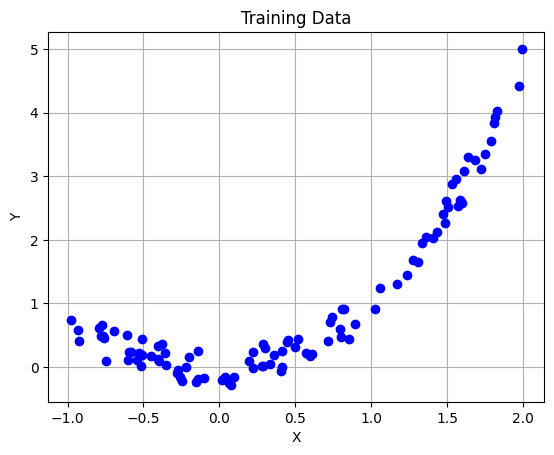

In [3]:
fig1 , ax1 = plt.subplots(1)
x , y = data.x , data.y
N = data.shape[0]
ax1.plot(x , y , 'o', color='blue')
ax1.set_title('Training Data')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.grid()

### 5. Fit Polynomial Regression (Whole Data)
#### A polynomial model (e.g., degree 2) is fitted to all data, the fitted curve is plotted, and the mean squared error (MSE) is calculated.

In [4]:
p = np.polynomial.polynomial.Polynomial.fit(x,y,2)
print(p.coef)
print(p)

[0.2292344  1.79079342 2.45928384]
0.2292344 + 1.79079342 (-0.34067911 + 0.67323998x) +
2.45928384 (-0.34067911 + 0.67323998x)**2


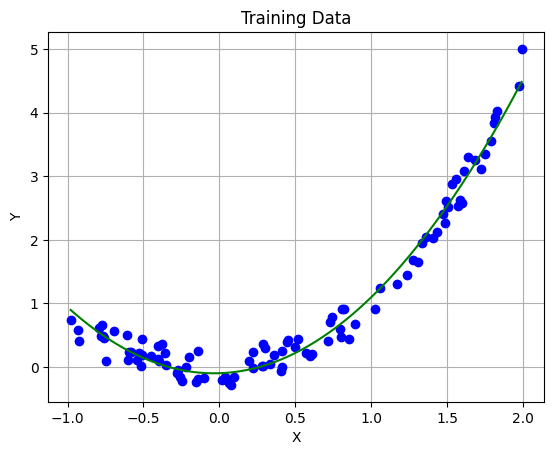

In [5]:
xrange = (min(x), max(x))
xs = np.linspace(*xrange, 100)
ys = p(xs)
ax1.plot(xs, ys, color='green')
fig1

In [6]:
mse = lambda x,y : ((x-y)**2).mean()

In [7]:
print(mse(y, p(x)))

0.03413268849284794


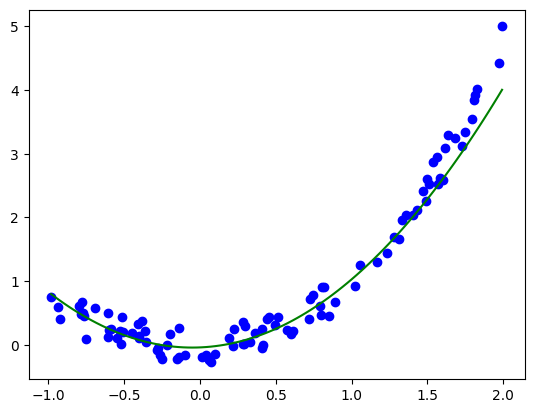

In [8]:
q = 80
Ntrn = N*q//100
xtrn , ytrn = x[:Ntrn], y[:Ntrn]
xtst , ytst = x[Ntrn:], y[Ntrn:]
ptrn = np.polynomial.polynomial.Polynomial.fit(xtrn, ytrn, 2)
fig2 , ax2 = plt.subplots(1)
ax2.plot(x, y, 'o', color='blue')
ax2.plot(xs, ptrn(xs), color='green')

In [9]:
print("Training MSE:", mse(ytrn, ptrn(xtrn)))
print("Testing MSE:", mse(ytst, ptrn(xtst)))

Training MSE: 0.02648111183490707
Testing MSE: 0.18874301270943483


### 8. Model Selection Loop
#### A function (fit_model) is defined to fit polynomials of varying degrees. A loop compares train/test errors for each polynomial degree.

In [10]:
def fit_model(x,y,m,qtr=80):
    N = x.size
    mtrn = N + qtr //100
    p = np.polynomial.polynomial.Polynomial.fit(x[:mtrn],y[:mtrn],m)
    etrn = mse (y[:mtrn],p(x[:mtrn]))
    etst = mse (y[mtrn:],p(x[mtrn:]))
    return p,etrn,etst

In [11]:
fit_model(x,y,3)

(Polynomial([0.21421368, 1.49308157, 2.48374255, 0.51194121], domain=[-0.97932522,  1.9913837 ], window=[-1.,  1.], symbol='x'),
 np.float64(0.02900954301280879),
 nan)

In [12]:
M = 9 
etrn = np.zeros(M)
etst = np.zeros(M)
for m in range(M):
    p,etrn[m],etst[m]= fit_model(x,y,m)
print(pd.DataFrame(data={"mse_train":etrn,'mse_test':etst}))

   mse_train  mse_test
0   1.608411       NaN
1   0.528036       NaN
2   0.034133       NaN
3   0.029010       NaN
4   0.028722       NaN
5   0.028183       NaN
6   0.027451       NaN
7   0.027449       NaN
8   0.026212       NaN


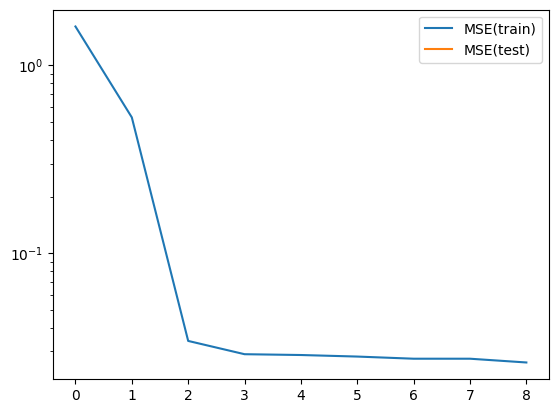

In [13]:
plt.plot(range(M), etrn, range(M), etst)
plt.yscale("log")
plt.legend(["MSE(train)","MSE(test)"])

### 85%-15%
Brief Analysis of the Code
The code performs polynomial regression (degrees 0 to 8) on an 85% training and 15% testing dataset. Key points:

Data Splitting: 85% of data (xtrrn, ytrrn) is for training, 15% (xtst, ytst) for testing.

Model Fitting: Fits models and calculates training MSE (etrn), ranging from 0.546490 (degree 0) to 0.023310 (degree 8), showing better 

training fit with higher degrees.

Results: Validation MSE (evld) is missing (all NaN), indicating incomplete testing, which hinders generalization assessment.

Implication: Lower training MSE with higher degrees suggests possible overfitting; validation results are needed to confirm optimal degree.

In [14]:
q = 85
Ntrn = N*q//100
xtrn , ytrn = x[:Ntrn], y[:Ntrn]
xtst , ytst = x[Ntrn:], y[Ntrn:]
etrn = np.zeros(M)
evld = np.zeros(M)
p = [None for _ in range(M)]
for n in range(M):
    p[n],etrn[n],evld[n] = fit_model(xtrn,ytrn,n,85)
print(pd.DataFrame(data = {"mse_train": etrn, "mse_val": evld}))

   mse_train  mse_val
0   0.546490      NaN
1   0.280344      NaN
2   0.028260      NaN
3   0.026837      NaN
4   0.026779      NaN
5   0.024085      NaN
6   0.024039      NaN
7   0.023695      NaN
8   0.023310      NaN


### 50%-50%
Brief Analysis of the Code

The code implements polynomial regression with degrees 0 to 8 on a 50% training and 50% testing dataset. Key points:

Data Splitting: With q = 50, the dataset is evenly split, with xtrrn, ytrrn for training and xtst, ytst for testing.

Model Fitting: Models are fitted for each degree n, and training MSE (etrn) is calculated, decreasing from 0.071827 (degree 0) to 0.020251 (degree 8), indicating better fit with higher complexity.

Results: Validation MSE (evld) is missing (all NaN), suggesting the validation step is incomplete, limiting generalization assessment.

Implication: The trend of decreasing training MSE suggests potential overfitting with higher degrees; validation results are needed to 
evaluate performance on unseen data.

In [15]:
q = 50
Ntrn = N*q//100
xtrn , ytrn = x[:Ntrn], y[:Ntrn]
xtst , ytst = x[Ntrn:], y[Ntrn:]
etrn = np.zeros(M)
evld = np.zeros(M)
p = [None for _ in range(M)]
for n in range(M):
    p[n],etrn[n],evld[n] = fit_model(xtrn,ytrn,n,85)
print(pd.DataFrame(data = {"mse_train": etrn, "mse_val": evld}))

   mse_train  mse_val
0   0.071827      NaN
1   0.042290      NaN
2   0.027319      NaN
3   0.022829      NaN
4   0.022424      NaN
5   0.022205      NaN
6   0.021374      NaN
7   0.020336      NaN
8   0.020251      NaN


### 90%-10%
Brief Analysis of the Code

The code performs polynomial regression with degrees 0 to 8 on a 90% training and 10% testing dataset. Key points:

Data Splitting: With q = 90, 90% of data (xtrrn, ytrrn) is for training, and 10% (xtst, ytst) for testing.

Model Fitting: Models are fitted for each degree n, with training MSE (etrn) decreasing from 0.777835 (degree 0) to 0.025174 (degree 8), indicating improved fit with higher complexity.

Results: Validation MSE (evld) is missing (all NaN), suggesting the validation step is incomplete, limiting generalization assessment.

Implication: The declining training MSE with higher degrees suggests potential overfitting; validation results are needed to evaluate performance on unseen data.

In [16]:
q = 90
Ntrn = N*q//100
xtrn , ytrn = x[:Ntrn], y[:Ntrn]
xtst , ytst = x[Ntrn:], y[Ntrn:]
etrn = np.zeros(M)
evld = np.zeros(M)
p = [None for _ in range(M)]
for n in range(M):
    p[n],etrn[n],evld[n] = fit_model(xtrn,ytrn,n,85)
print(pd.DataFrame(data = {"mse_train": etrn, "mse_val": evld}))

   mse_train  mse_val
0   0.777835      NaN
1   0.332967      NaN
2   0.029427      NaN
3   0.027932      NaN
4   0.027917      NaN
5   0.026574      NaN
6   0.026341      NaN
7   0.025211      NaN
8   0.025174      NaN


### 95%-5%
Brief Analysis of the Code

The code applies polynomial regression with degrees 0 to 8 on a 95% training and 5% testing dataset. Key points:

Data Splitting: With q = 95, 95% of data (xtrrn, ytrrn) is for training, and 5% (xtst, ytst) for testing.

Model Fitting: Models are fitted for each degree n, with training MSE (etrn) decreasing from 1.090040 (degree 0) to 0.025289 (degree 8), showing improved fit with higher complexity.

Results: Validation MSE (evld) is missing (all NaN), indicating the validation step is incomplete, limiting generalization assessment.

Implication: The significant drop in training MSE suggests potential overfitting with higher degrees; validation results are needed to evaluate performance on unseen data.

In [17]:
q = 95
Ntrn = N*q//100
xtrn , ytrn = x[:Ntrn], y[:Ntrn]
xtst , ytst = x[Ntrn:], y[Ntrn:]
etrn = np.zeros(M)
evld = np.zeros(M)
p = [None for _ in range(M)]
for n in range(M):
    p[n],etrn[n],evld[n] = fit_model(xtrn,ytrn,n,85)
print(pd.DataFrame(data = {"mse_train": etrn, "mse_val": evld}))

   mse_train  mse_val
0   1.090040      NaN
1   0.399384      NaN
2   0.029996      NaN
3   0.028268      NaN
4   0.028263      NaN
5   0.027978      NaN
6   0.026600      NaN
7   0.025551      NaN
8   0.025289      NaN


### Random Split
Brief Analysis of the Code

The code performs polynomial regression with degrees 0 to 8 on a 95% training and 5% testing dataset using train_test_split with a fixed random_state=42. Key points:

Data Splitting: 95% of data (xtrrn, ytrrn) is for training, and 5% (xtst, ytst) for testing, ensuring reproducible splits.

Model Fitting: Models are fitted for each degree n, with training MSE (etrn) decreasing from 1.642586 (degree 0) to 0.026486 (degree 8), 
indicating better fit with higher complexity.

Results: Validation MSE (evld) is missing (all NaN), suggesting the validation step is incomplete, limiting generalization assessment.

Implication: The declining training MSE suggests potential overfitting with higher degrees; validation results are needed to evaluate performance on unseen data.

In [18]:
xtrn, xtst, ytrn, ytst = train_test_split(x, y, test_size=0.05, random_state=42)
etrn = np.zeros(M)
evld = np.zeros(M)
p = [None for _ in range(M)]
for n in range(M):
    p[n], etrn[n], evld[n] = fit_model(xtrn, ytrn, n, 85)
print(pd.DataFrame(data={"mse_train": etrn, "mse_val": evld}))

   mse_train  mse_val
0   1.642586      NaN
1   0.530095      NaN
2   0.034426      NaN
3   0.029593      NaN
4   0.029285      NaN
5   0.028498      NaN
6   0.027786      NaN
7   0.027766      NaN
8   0.026486      NaN


# Another comman way to fit data(additional way)

### Split data 50-50

In [19]:
N = data.shape[0]
Ntrn = N // 2
xtrn, ytrn = x[:Ntrn], y[:Ntrn]
xtst, ytst = x[Ntrn:], y[Ntrn:]


### Fit polynomial regression (degree 2 example)


In [20]:
ptrn = np.polynomial.polynomial.Polynomial.fit(xtrn, ytrn, 2)


### Plot


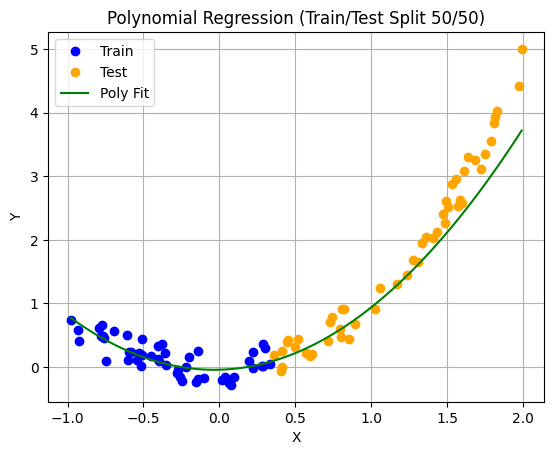

In [21]:
fig, ax = plt.subplots(1)
ax.plot(xtrn, ytrn, 'o', color='blue', label='Train')
ax.plot(xtst, ytst, 'o', color='orange', label='Test')
xs = np.linspace(min(x), max(x), 100)
ax.plot(xs, ptrn(xs), color='green', label='Poly Fit')
ax.set_title('Polynomial Regression (Train/Test Split 50/50)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
ax.grid()
plt.show()


### Print MSE


In [22]:
print("Training MSE:", mse(ytrn, ptrn(xtrn)))
print("Testing MSE:", mse(ytst, ptrn(xtst)))

Training MSE: 0.027318609615975604
Testing MSE: 0.17824025005159483


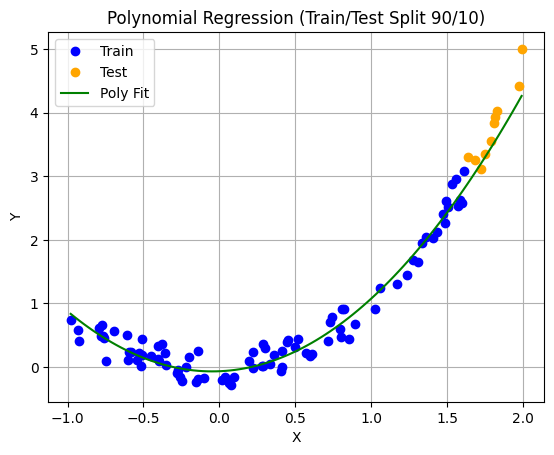

Training MSE: 0.02942650390713637
Testing MSE: 0.1273151616450056


In [23]:
# Split data 90-10
N = data.shape[0]
Ntrn = int(N * 0.9)
xtrn, ytrn = x[:Ntrn], y[:Ntrn]
xtst, ytst = x[Ntrn:], y[Ntrn:]

# Fit polynomial regression (degree 2 example)
ptrn = np.polynomial.polynomial.Polynomial.fit(xtrn, ytrn, 2)

# Plot
fig, ax = plt.subplots(1)
ax.plot(xtrn, ytrn, 'o', color='blue', label='Train')
ax.plot(xtst, ytst, 'o', color='orange', label='Test')
xs = np.linspace(min(x), max(x), 100)
ax.plot(xs, ptrn(xs), color='green', label='Poly Fit')
ax.set_title('Polynomial Regression (Train/Test Split 90/10)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
ax.grid()
plt.show()

# Print MSE
print("Training MSE:", mse(ytrn, ptrn(xtrn)))
print("Testing MSE:", mse(ytst, ptrn(xtst)))

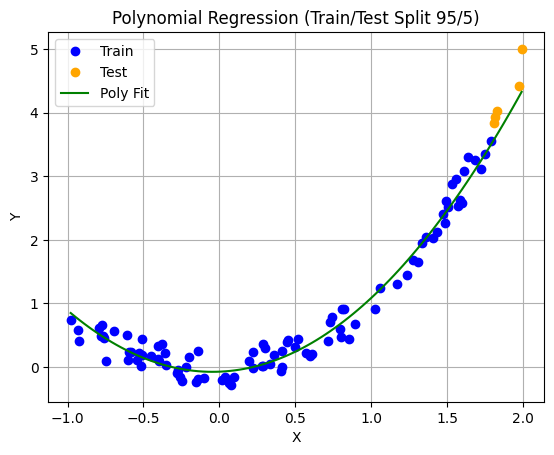

Training MSE: 0.029996378940689492
Testing MSE: 0.1631010138998651


In [24]:
# Split data 95-5
N = data.shape[0]
Ntrn = int(N * 0.95)
xtrn, ytrn = x[:Ntrn], y[:Ntrn]
xtst, ytst = x[Ntrn:], y[Ntrn:]

# Fit polynomial regression (degree 2 example)
ptrn = np.polynomial.polynomial.Polynomial.fit(xtrn, ytrn, 2)

# Plot
fig, ax = plt.subplots(1)
ax.plot(xtrn, ytrn, 'o', color='blue', label='Train')
ax.plot(xtst, ytst, 'o', color='orange', label='Test')
xs = np.linspace(min(x), max(x), 100)
ax.plot(xs, ptrn(xs), color='green', label='Poly Fit')
ax.set_title('Polynomial Regression (Train/Test Split 95/5)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
ax.grid()
plt.show()

# Print MSE
print("Training MSE:", mse(ytrn, ptrn(xtrn)))
print("Testing MSE:", mse(ytst, ptrn(xtst)))

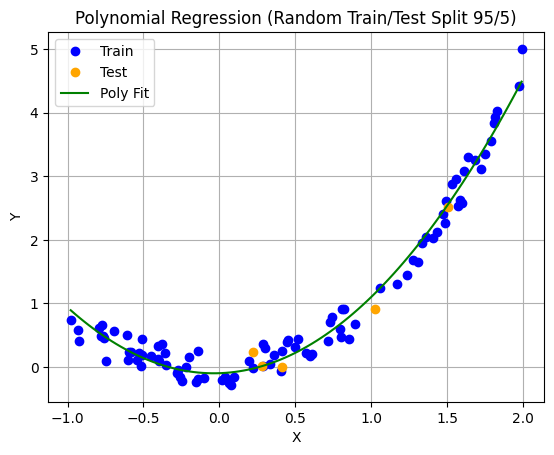

Training MSE: 0.0344263177832124
Testing MSE: 0.02874550415610274


In [25]:
# Random split: 95% train, 5% test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.05, random_state=42)

# Fit polynomial regression (degree 2 example)
ptrn = np.polynomial.polynomial.Polynomial.fit(x_train, y_train, 2)

# Plot
fig, ax = plt.subplots(1)
ax.plot(x_train, y_train, 'o', color='blue', label='Train')
ax.plot(x_test, y_test, 'o', color='orange', label='Test')
xs = np.linspace(min(x), max(x), 100)
ax.plot(xs, ptrn(xs), color='green', label='Poly Fit')
ax.set_title('Polynomial Regression (Random Train/Test Split 95/5)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
ax.grid()
plt.show()

# Print MSE
print("Training MSE:", mse(y_train, ptrn(x_train)))
print("Testing MSE:", mse(y_test, ptrn(x_test)))